In [1]:
import plumed
import matplotlib.pyplot as plt
import numpy as np
import subprocess
import os

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
/tmp/ipykernel_136474/948421981.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_c = plumed.read_as_pandas(fesfile_c)
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
/tmp/ipykernel_136474/948421981.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_m = plumed.read_as_pandas(fesfile_m)


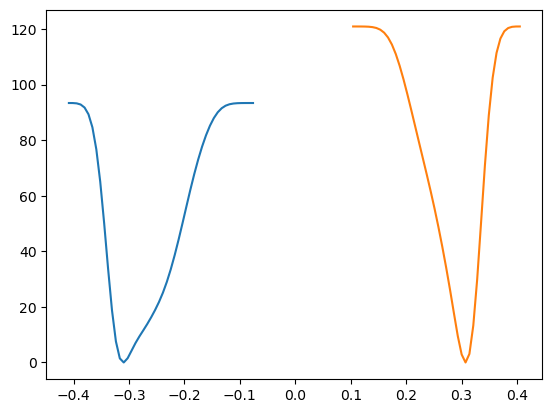

In [2]:
runnum=4
date="011426"
fesfile_c = f"/home/jonathan/Documents/grabelab/aac1-nt-transport/metadynamics/run{runnum}/run_c/summed_hills/fes-{date}.dat"
fesfile_m = f"/home/jonathan/Documents/grabelab/aac1-nt-transport/metadynamics/run{runnum}/run_m/summed_hills/fes-{date}.dat"


#read and plot metadynamics potential
data_c = plumed.read_as_pandas(fesfile_c)
c_pc_f1b = list(data_c["pc_f1b"])
c_energy = list(data_c["file.free"])

plt.plot(c_pc_f1b, c_energy)

data_m = plumed.read_as_pandas(fesfile_m)
m_pc_f1b = list(data_m["pc_f1b"])
m_energy = list(data_m["file.free"])
plt.plot(m_pc_f1b, m_energy)

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
/tmp/ipykernel_136474/411607305.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  colvar=plumed.read_as_pandas(infile)
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
/tmp/ipykernel_136474/411607305.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  colvar=plumed.read_as_pandas(infile)
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
/tmp/ipykernel_136474/411607305.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instea

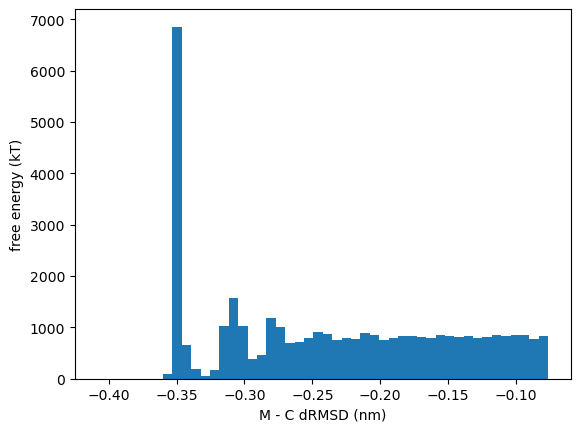

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
/tmp/ipykernel_136474/411607305.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  colvar=plumed.read_as_pandas(infile)
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
/tmp/ipykernel_136474/411607305.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  colvar=plumed.read_as_pandas(infile)
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
/tmp/ipykernel_136474/411607305.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instea

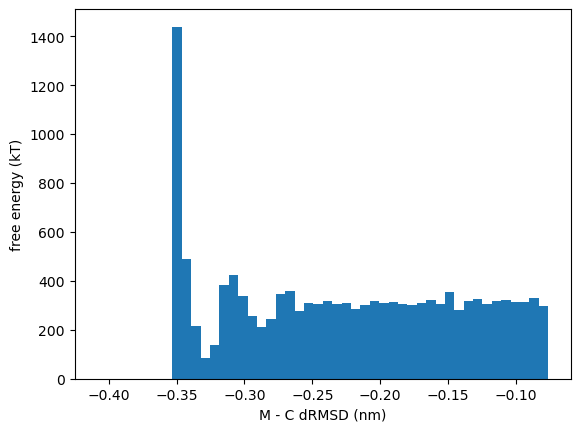

In [ ]:
nbins = len(c_pc_f1b)
min_pc = min(c_pc_f1b)
max_pc = max(c_pc_f1b)


nwalkers = 8
for init_state in ["c","m"]:

    delta_all = []
    #sigma_all = []

    for walker in range(nwalkers):
        infile = f"/home/jonathan/Documents/grabelab/aac1-nt-transport/metadynamics/run3/run_{init_state}/COLVAR.{walker}"
        #infile = f"/home/jonathan/Documents/grabelab/aac1-ucp1/aac1/trajectories/plumed_tests/plumed/sys{system}/mwm{runnum}/{walker}/COLVAR"
        colvar=plumed.read_as_pandas(infile)

        freq = 1

        delta = list(colvar.pc_f1b[::freq])

        pc_c = list(colvar.pc_fc[::freq])
        pc_m = list(colvar.pc_fm[::freq])
        sigma = [i+j for i,j in zip(pc_c,pc_m)]

        delta_all+=delta
        #sigma_all+=sigma


    if init_state == "c":
        minx = delta_all[0]
    else:
        minx = -delta_all[0]
    #plt.figure(figsize=(4,4),dpi=600)
    plt.hist(delta_all, bins=nbins, range=[min_pc, max_pc])

    plt.xlabel("M - C dRMSD (nm)")
    plt.ylabel("number of frames")
    plt.show()